# Fantastic Datasets and Where to Find Them

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai-builders/curriculum/blob/main/notebooks/02_fantastic_datasets_2026.ipynb)

## What You'll Learn

Welcome to **Fantastic Datasets and Where to Find Them**, Lesson 2 of the AI Builders curriculumー2026 edition.

In Lesson 1 you learned *what* AI systems are and *how* they learn (the training loop). But every training loop needs fuel: **data**. The quality and quantity of your data often matters more than the model you choose.

In this notebook we will cover:

1. **Data-Centric AI**; why data quality beats model size, with real evidence
2. **Where to find datasets**; open data sources, task taxonomies, and licensing
3. **Building an image dataset from search**; image search → download → verify → clean
4. **Loading and exploring existing data**; HuggingFace Datasets + quick EDA with pandas
5. **Web scraping**; collecting your own data from static and dynamic websites
6. **Generating synthetic data**; text (DSPy + Qwen3-0.6B), images (Tiny Stable Diffusion), and tabular (with reference to [AdaRec](https://github.com/amazon-science/AdaRec))
7. **Data quality checklist**; rubric-aligned checks to make sure your data is project-ready
8. **Your data plan**; a fill-in template to prepare for your project

By the end, you will have hands-on experience with every major way to obtain training data and the judgment to know which approach fits your project.

## Environment Setup

The cell below detects whether you are running on **Google Colab** or **locally**.

- **Colab**: dependencies are installed automatically via `pip`.
- **Local** (e.g. MacBook Pro with Apple Silicon): set up your environment with `uv`:

```bash
uv pip install dspy torch transformers bitsandbytes accelerate fastai \
    matplotlib datasets icrawler beautifulsoup4 requests \
    pandas diffusers google-colab-selenium
```

Or if you have a `requirements.txt`:

```bash
uv pip install -r requirements.txt
```

In [1]:
import os, subprocess, sys

# --- Detect environment ---
IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

LESSON_2_DEPS = [
    "dspy", "torch", "transformers", "bitsandbytes", "accelerate",
    "fastai", "matplotlib", "datasets",
    "icrawler", "beautifulsoup4", "requests",
    "pandas", "diffusers",
]

if IN_COLAB:
    print("Running on Google Colab — installing dependencies...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         *LESSON_2_DEPS, "google-colab-selenium"]
    )
    print("Done!")
else:
    print("Running locally. Make sure you've set up your environment:")
    print(f"  uv pip install {' '.join(LESSON_2_DEPS)}")
    print("Or: uv pip install -r requirements.txt")

# --- Device setup ---
import torch

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon MPS")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print(f"\nDevice: {DEVICE}")

Running locally. Make sure you've set up your environment:
  uv pip install dspy torch transformers bitsandbytes accelerate fastai matplotlib datasets icrawler beautifulsoup4 requests pandas diffusers
Or: uv pip install -r requirements.txt
Using Apple Silicon MPS

Device: mps


## 1. Data-Centric AI — Why Data Quality Beats Model Size

The [Data-Centric AI](https://datacentricai.org/) movement, popularized by Andrew Ng, argues that instead of endlessly tweaking model architectures, we should spend more time improving our data: its quantity, quality, and diversity. Here are three landmark results that prove the point.

### LIMA: Less Is More for Alignment

[Zhou et al. (2023)](https://arxiv.org/abs/2305.11206) fine-tuned LLaMA-65B on just **1,000 carefully curated examples** using simple self-supervision and produced a model whose outputs were competitive with models trained with RLHF on orders of magnitude more data.

The key insight: the 1,000 examples were *meticulously selected and cleaned* by the authors. Quality of data dominated quantity.

| Comparison | LIMA Preferred or Equivalent |
|---|---|
| LIMA (1,000 examples) vs. DaVinci-003 (RLHF-trained) | 65% |
| LIMA (1,000 examples) vs. Bard | 58% |
| LIMA (1,000 examples) vs. GPT-4 | 43% |

A model fine-tuned on just 1,000 hand-curated examples was preferred over DaVinci-003 nearly two-thirds of the time — and held its own against GPT-4 in almost half the comparisons.

### Chinchilla and Llama 3: More Data > Bigger Model

[Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556) — the "Chinchilla" paper — showed that most large language models were *undertrained*. Given a fixed compute budget, you get better results by training a smaller model on more data than training a larger model on less data, the optimal point being about 20 tokens per 1 model parameter.

The paper fits a scaling law for language model loss:

$$L(N, D) = E + \frac{A}{N^\alpha} + \frac{B}{D^\beta}$$

where $N$ = parameters, $D$ = training tokens, and $E, A, B, \alpha, \beta$ are fitted constants. The first power-law term captures the benefit of a bigger model; the second captures the benefit of more data. Let’s plot this to see the tradeoff visually.

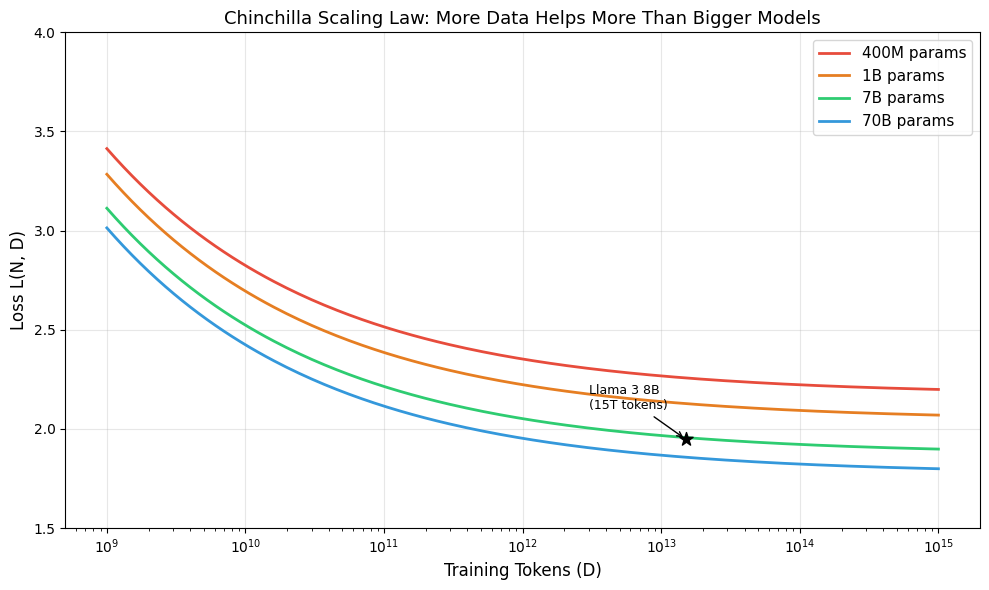

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Chinchilla scaling law: L(N, D) = E + A/N^alpha + B/D^beta
# Fitted constants from Hoffmann et al. (2022), Approach 3
E, A, B = 1.69, 406.4, 410.7
alpha, beta = 0.34, 0.28

def chinchilla_loss(N, D):
    return E + A / N**alpha + B / D**beta

# Training tokens (x-axis): 1B to 10T
D = np.logspace(9, 15, 200)

# Different model sizes
model_sizes = {
    '400M':  400e6,
    '1B':    1e9,
    '7B':    7e9,
    '70B':   70e9,
}

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))

for (label, N), color in zip(model_sizes.items(), colors):
    loss = chinchilla_loss(N, D)
    ax.plot(D, loss, label=f'{label} params', color=color, linewidth=2)

# Mark where Llama 3 8B sits (8B params, 15T tokens)
llama3_loss = chinchilla_loss(8e9, 15e12)
ax.scatter([15e12], [llama3_loss], color='black', s=100, zorder=5, marker='*')
ax.annotate('Llama 3 8B\n(15T tokens)', xy=(15e12, llama3_loss),
            xytext=(3e12, llama3_loss + 0.15), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xscale('log')
ax.set_xlabel('Training Tokens (D)', fontsize=12)
ax.set_ylabel('Loss L(N, D)', fontsize=12)
ax.set_title('Chinchilla Scaling Law: More Data Helps More Than Bigger Models',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(1.5, 4.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Each curve shows how loss decreases as you feed more data to a model of a given size. Notice two things:

1. **Curves flatten** — at some point, adding more data to a small model stops helping. The model is too small to absorb more information.
2. **Bigger models need more data** — the 70B curve is still dropping where the 400M curve has already plateaued. But if you only train the 70B model on 1B tokens, it actually performs *worse* than a 1B model trained on 100B tokens.

The Chinchilla insight: **for a fixed compute budget, there is an optimal balance between model size and data**. Most models before Chinchilla were too big for their data. Meta’s Llama 3 (marked with ★) pushed this to the extreme — training an 8B model on 15T tokens, far beyond what earlier scaling laws would have suggested.

### Phi-1: Textbooks Are All You Need

[Gunasekar et al. (2023)](https://arxiv.org/abs/2306.11644) trained **Phi-1**, a 1.3B parameter model, on high-quality "textbook-grade" synthetic data generated by GPT-3.5. Despite being tiny by LLM standards, Phi-1 beat models 10x its size on coding benchmarks:

| Model | Parameters | Training Data | HumanEval (pass@1) | MBPP (pass@1) |
|---|---|---|---|---|
| StarCoder-Prompted | 15.5B | 1T tokens (The Stack) | 40.8% | 49.5% |
| GPT-3.5 | 175B | Unknown (massive) | 47.0% | — |
| **phi-1** | **1.3B** | **7B tokens (textbook-quality)** | **50.6%** | **55.5%** |
| GPT-4 | Unknown (massive) | Unknown (massive) | 67.0% | — |

phi-1 beat GPT-3.5 (which is 135x larger) and StarCoder (which is 12x larger and trained on 140x more data). The secret was not scale — it was **data quality**. The 7B tokens of textbook-grade synthetic data were worth more than 1T tokens of raw code from the internet.

This connects directly to what we will do later in this notebook: **generating synthetic data** with LLMs.

```
The Data-Centric Insight:

  Better data  →  Better model   (always true)
  Bigger model →  Better results  (only if you also have enough good data)
```

### The Data Effort Spectrum

For your AI Builders project, the data you use must involve **non-trivial effort**. You cannot simply download a clean Kaggle dataset, train a model, and call it a day. Here is how we think about data effort:

```
Level 1 (minimal)     → Download a clean dataset, use as-is          ← NOT ENOUGH
Level 2 (moderate)    → Combine multiple sources, clean & transform  ← Barely acceptable
Level 3 (significant) → Scrape/collect raw data, label it yourself   ← Good
Level 4 (advanced)    → Generate + curate synthetic data, or build   ← Excellent
                       a novel dataset from scratch
```

Why? Because the hard part of real-world ML is almost never the model; it is getting good data. If you skip that step, you skip the most important skill.

The rest of this notebook teaches you the skills for Levels 2–4.

## 2. Where to Find Datasets

Before you build anything, you need to know where to look. The landscape of open datasets has consolidated significantly to a few platforms that cover most needs.

### Open Data Sources

**General-purpose**
- [HuggingFace Datasets](https://huggingface.co/datasets) — the dominant hub for all modalities: text, images, audio, tabular, multimodal. Over 200,000 datasets with standardized loading via `load_dataset()`.
- [Kaggle Datasets](https://www.kaggle.com/datasets) — large community, many competition datasets with notebooks showing how others used them.
- [Google Dataset Search](https://datasetsearch.research.google.com/) — a search engine specifically for datasets across the web.
- [Papers with Code](https://paperswithcode.com/datasets) — datasets linked to the papers and benchmarks that use them.

**Images**
- [Open Images Dataset](https://storage.googleapis.com/openimages/web/index.html) — 9M images with labels for classification, detection, segmentation.
- [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html) — classic benchmarks (CIFAR, ImageNet, MNIST, etc.) with one-line loading.

**Text and Speech**
- [HuggingFace Datasets](https://huggingface.co/datasets) — this is where most NLP datasets live now.
- [Common Crawl](https://commoncrawl.org/) — petabytes of raw web text, the source behind most LLM training data.

**Tabular**
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/) — the classic collection of tabular ML datasets.
- [OpenML](https://www.openml.org/) — thousands of tabular datasets with standardized metadata and benchmarks.

### Task Names for Searching

A practical trick: search for `"[task name] dataset"` in any search engine or on HuggingFace. Here are the major task names organized by modality:

**Images**
- Image classification — categorize images into classes
- Object detection — locate and label objects in images
- Image segmentation — classify each pixel
- Image captioning — generate text descriptions of images
- Visual question answering (VQA) — answer questions about images
- Image generation — create images from text or other inputs
- Depth estimation — predict distance from camera for each pixel
- Pose estimation - predict points and skeletons in human movements

**Text**
- Text classification — categorize text
- Named entity recognition (NER) — identify entities in text
- Question answering — answer questions from context
- Machine translation — translate between languages
- Summarization — condense long text
- Text generation — produce text from prompts
- Retrieval / semantic search — find relevant documents

**Speech and Audio**
- Automatic speech recognition (ASR) — transcribe speech to text
- Text-to-speech (TTS) — generate speech from text
- Speaker recognition — identify who is speaking
- Audio classification — categorize sounds

**Tabular**
- Classification — predict a category from features
- Regression — predict a continuous value
- Time series forecasting — predict future values
- Recommendation — suggest items to users
- Anomaly detection — find unusual patterns
- Clustering - group examples together

**Multimodal and Agentic** 
- Visual grounding — link text phrases to image regions
- Document understanding — extract structured info from PDFs/forms
- Tool use / function calling — train models to use APIs and tools
- Instruction following — evaluate how well models follow complex instructions

### Licensing — Know Before You Use

Open data is shared under licenses that define what you can and cannot do. The most common family is [Creative Commons](https://creativecommons.org/):

| Code | Meaning |
|---|---|
| `CC` | Creative Commons |
| `BY` (Attribution) | You can use, copy, modify — but must credit the creator |
| `SA` (ShareAlike) | Derivatives must keep the same license |
| `NC` (NonCommercial) | No commercial use |
| `ND` (NoDerivatives) | No modifications allowed |

For your projects, we recommend sharing your work as **CC-BY-SA** — it lets the community build on your work, just as you build on theirs.

**A note on LLM-generated data**: If you use an LLM to generate training data, check the model's terms of service. Some providers restrict using their outputs to train competing models. Open-weight models (Llama, Qwen, Mistral) generally have more permissive licenses for generated content.

You can choose your license at [creativecommons.org/choose](https://creativecommons.org/choose/).

## 3. Building an Image Dataset from Search

Sometimes you need an image dataset that does not exist yet. A fast way to bootstrap one is to search for images online, download them, and clean up the failures.

This technique was popularized by [fastai](https://course.fast.ai/). We use [icrawler](https://github.com/hellock/icrawler) with the **Bing** backend because it handles rate limiting internally and does not require an API key.

Let's build a tiny image classifier dataset: **chihuahua vs. blueberry muffin**.

<img src='../images/chihuahua_vs_muffin.png' width=400/>

In [2]:
from pathlib import Path
from icrawler.builtin import BingImageCrawler
from fastai.vision.utils import verify_images
from fastai.data.transforms import get_image_files

# Where to save images
path = Path('images_lesson2')

# Short folder names (used as class labels) mapped to search queries
searches = {'dog': 'chihuahua', 'muffin': 'blueberry muffin'}
MAX_N = 50

for folder_name, query in searches.items():
    dest = path / folder_name
    print(f'Downloading "{query}" -> {dest}/')
    crawler = BingImageCrawler(
        storage={'root_dir': str(dest)},
        log_level=20,  # INFO
    )
    crawler.crawl(keyword=query, max_num=MAX_N)
    print()

2026-04-02 21:12:24,989 - INFO - icrawler.crawler - start crawling...
2026-04-02 21:12:24,989 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-02 21:12:24,989 - INFO - feeder - thread feeder-001 exit
2026-04-02 21:12:24,990 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-02 21:12:24,991 - INFO - icrawler.crawler - starting 1 downloader threads...


2026-04-02 21:12:25,262 - INFO - parser - parsing result page https://www.bing.com/images/async?q=chihuahua&first=0
2026-04-02 21:12:25,273 - INFO - downloader - skip downloading file 000001.jpg
2026-04-02 21:12:25,274 - INFO - downloader - skip downloading file 000002.jpg
2026-04-02 21:12:25,274 - INFO - downloader - skip downloading file 000003.jpg
2026-04-02 21:12:25,274 - INFO - downloader - skip downloading file 000004.jpg
2026-04-02 21:12:25,275 - INFO - downloader - skip downloading file 000005.jpg
2026-04-02 21:12:25,275 - INFO - downloader - skip downloading file 000006.jpg
2026-04-02 21:12:25,276 - INFO - downloader - skip downloading file 000007.jpg
2026-04-02 21:12:25,276 - INFO - downloader - skip downloading file 000008.jpg
2026-04-02 21:12:25,276 - INFO - downloader - skip downloading file 000009.jpg
2026-04-02 21:12:25,277 - INFO - downloader - skip downloading file 000010.jpg
2026-04-02 21:12:25,277 - INFO - downloader - skip downloading file 000011.jpg
2026-04-02 21:1

2026-04-02 21:12:35,345 - INFO - parser - parsing result page https://www.bing.com/images/async?q=blueberry muffin&first=0
2026-04-02 21:12:35,356 - INFO - downloader - skip downloading file 000001.jpg
2026-04-02 21:12:35,356 - INFO - downloader - skip downloading file 000002.jpg
2026-04-02 21:12:35,357 - INFO - downloader - skip downloading file 000003.jpg
2026-04-02 21:12:35,357 - INFO - downloader - skip downloading file 000004.jpg
2026-04-02 21:12:35,357 - INFO - downloader - skip downloading file 000005.jpg
2026-04-02 21:12:35,358 - INFO - downloader - skip downloading file 000006.jpg
2026-04-02 21:12:35,358 - INFO - downloader - skip downloading file 000007.jpg
2026-04-02 21:12:35,358 - INFO - downloader - skip downloading file 000008.jpg
2026-04-02 21:12:35,359 - INFO - downloader - skip downloading file 000009.jpg
2026-04-02 21:12:35,359 - INFO - downloader - skip downloading file 000010.jpg
2026-04-02 21:12:35,360 - INFO - downloader - skip downloading file 000011.jpg
2026-04-

In [ ]:
# Check what we got
fns = get_image_files(path)
print(f'Total images downloaded: {len(fns)}')

# Verify — some downloads will be corrupted
failed = verify_images(fns)
print(f'Failed/corrupted images: {len(failed)}')

# Remove the bad ones
failed.map(Path.unlink)

# Final count
fns = get_image_files(path)
print(f'Clean images remaining: {len(fns)}')

Total images downloaded: 100
Failed/corrupted images: 0
Clean images remaining: 100


2026-04-02 21:12:45,766 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-04-02 21:12:45,766 - INFO - parser - thread parser-001 exit


That is it. You now have a labeled image dataset built from scratch. The labels come from the search query (the folder name), and the images come from the web.

Now let’s see how easy the *model training* part is, and why that’s exactly the problem.

### Training a Model Is the Easy Part

With fastai, training an image classifier on our cookie dataset takes a few lines of code and under a minute of compute.

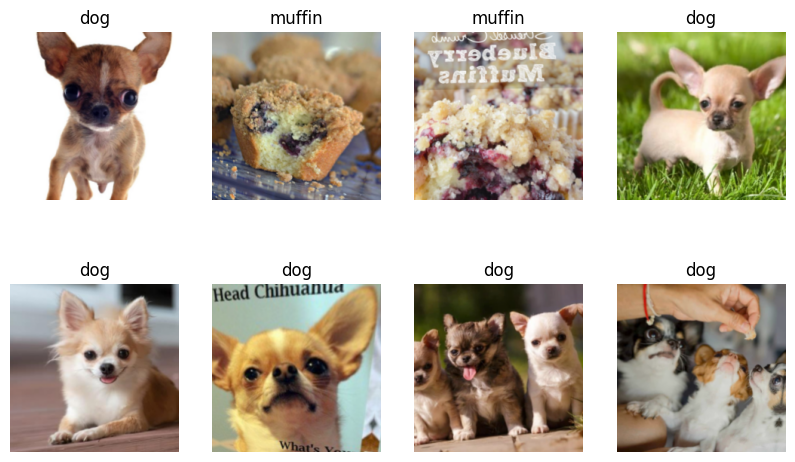

In [4]:
from fastai.vision.all import *

# Build a DataLoaders object from our folder structure
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,       # 20% for validation
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    seed=42,
)

# Show a batch to see what the model will train on
dls.show_batch(max_n=8, figsize=(10, 6))

In [5]:
# Fine-tune a pretrained ResNet34 — this is the entire training step
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.652131,0.849053,0.600000,00:02


epoch,train_loss,valid_loss,accuracy,time
0,1.059289,0.480237,0.600000,00:01
1,0.897334,0.059844,1.000000,00:01
2,0.622474,0.027192,1.000000,00:01


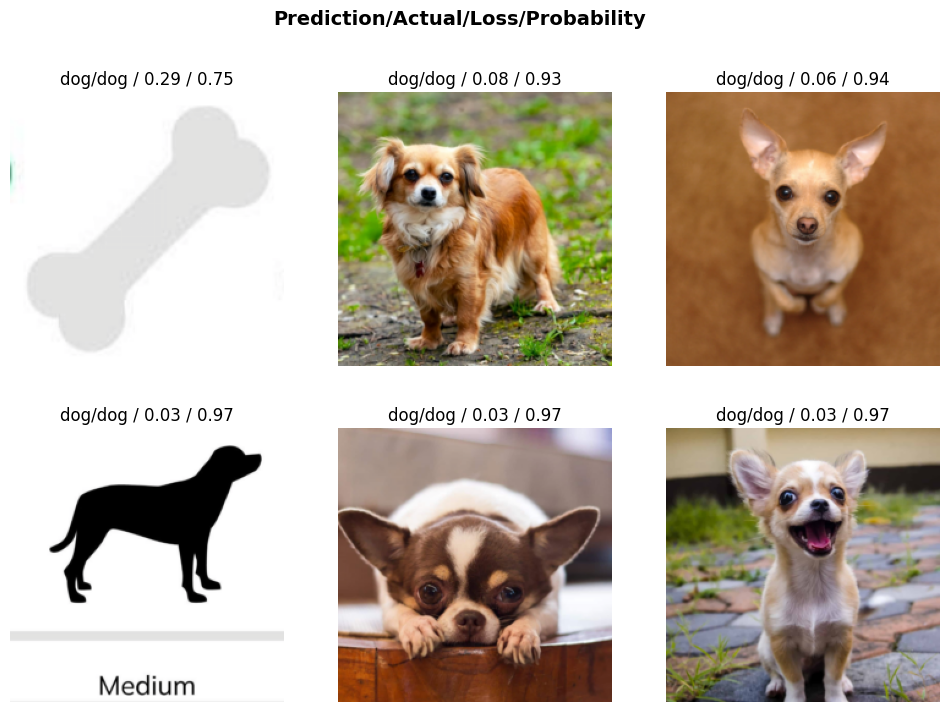

In [6]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(6, figsize=(12, 8))

### The Model Was Easy. The Data Is the Problem.

That took about 30 seconds of your time and a few minutes of compute. You now have a chihuahua-vs-muffin classifier. Congratulations?

Now look at the top losses above: the images the model is most confused about. You will likely see several categories of problems:

- **Irrelevant images** — not every search result is what you asked for. You will find cartoon dogs, logos, memes, screenshots of articles, or completely unrelated photos mixed into your dataset. The model has no way to know these do not belong.

- **Wrong kind of correct** — the chihuahua folder probably contains chihuahuas in all sorts of poses: standing in a park, wearing a sweater, sitting on a couch. But the whole point of this task is to classify images where chihuahuas *look like muffins* — close-up face shots with round features. A full-body chihuahua running on grass is technically a correct label, but it does not help the model learn the decision boundary we actually care about.

- **Genuinely ambiguous cases** — some images are legitimately hard. A close-up of a chihuahua face *does* look like a muffin. These are the cases we *want* the model to learn from — but they are buried under all the noise.

This is the point: **training the model is trivial. Curating the data is where the real work happens.** A few lines of training code are not your bottleneck — the 50 images of chihuahuas-in-sweaters diluting your dataset are.

For a project, you would:

1. Manually inspect every image (or at least a large sample)
2. Remove irrelevant images and images that do not match your actual task
3. Re-train and check the top losses again
4. Repeat until the errors are genuine hard cases, not data quality issues

This is **Level 3** data effort — and it is the minimum bar for your project.

> **Try it yourself**: Change the labels to something you care about — dog breeds, car models, types of flowers — and build your own dataset. But this time, actually look at the images before you train.

## 4. Loading and Exploring Existing Data

Most of the time, you will start with an existing dataset and transform it for your needs. [HuggingFace Datasets](https://huggingface.co/datasets) makes loading standardized datasets trivial.

In [7]:
from datasets import load_dataset
import pandas as pd

# Load a text classification dataset
ds = load_dataset("stanfordnlp/imdb", split="train")

print(f"Dataset: {ds}")
print(f"Number of examples: {len(ds)}")
print(f"Features: {ds.features}")
print(f"\nFirst example:")
print(f"  Label: {ds[0]['label']} (0=negative, 1=positive)")
print(f"  Text:  {ds[0]['text'][:200]}...")

2026-04-02 21:14:33,291 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-02 21:14:33,314 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
2026-04-02 21:14:33,490 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
2026-04-02 21:14:34,057 - INFO - httpx - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/stanfordnlp/imdb/stanfordnlp/imdb.py "HTTP/1.1 404 Not Found"
2026-04-02 21:14:34,247 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/datasets/stanfordnlp/imdb/revision/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 "HTTP/1.1 200 OK"
2026-04-02 21:14:34,428 - INFO - httpx - HTTP Request: HEAD https://huggingfac

Dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Number of examples: 25000
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

First example:
  Label: 0 (0=negative, 1=positive)
  Text:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...


### Quick EDA with pandas

Before training any model, always look at your data. Here are the checks you should run on every dataset.

In [8]:
# Convert to pandas for easier exploration
df = ds.to_pandas()

# 1. Shape — how big is the dataset?
print(f"Shape: {df.shape}")
print()

# 2. Class distribution — is it balanced?
print("Class distribution:")
print(df["label"].value_counts())
print()

# 3. Missing values?
print("Missing values:")
print(df.isnull().sum())
print()

# 4. Text length distribution — are there outliers?
df["text_length"] = df["text"].str.len()
print("Text length stats:")
print(df["text_length"].describe())

Shape: (25000, 2)

Class distribution:
label
0    12500
1    12500
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64

Text length stats:
count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: text_length, dtype: float64


In [9]:
df.tail()

,text,label,text_length
24995,"A hit at the time but now better categorised as an Australian cult film. The humour is broad, unsubtle and, in the final scene where a BBC studio fire is extinguished by urinating on it, crude. Contains just about every cliche about the traditional Australian pilgrimage to 'the old country', and every cliche about those rapacious, stuck up, whinging, Tory Brits. Would be acceptable to the British because of its strong cast of well known actors, and to Australians of that generation, who can 'get' the humour. Americans -- forget it. The language and jokes are in the Australian dialect of En...",1,637
24996,"I love this movie like no other. Another time I will try to explain its virtues to the uninitiated, but for the moment let me quote a few of pieces the remarkable dialogue, which, please remember, is all tongue in cheek. Aussies and Poms will understand, everyone else-well?<br /><br />(title song lyric)""he can sink a beer, he can pick a queer, in his latest double-breasted Bondi gear.""<br /><br />(another song lyric) ""All pommies are bastards, bastards, or worse, and England is the a**e-hole of the universe.""<br /><br />(during a television interview on an ""arty program""): Mr Mackenzie wha...",1,1091
24997,"This film and it's sequel Barry Mckenzie holds his own, are the two greatest comedies to ever be produced. A great story a young Aussie bloke travels to england to claim his inheritance and meets up with his mates, who are just as loveable and innocent as he is.<br /><br />It's chock a block full of great, sayings , where else could you find someone who needs a drink so bad that he's as dry as a dead dingoes donger? great characters, top acting, and it's got great sheilas and more Fosters consumption then any other three films put together. Top notch.<br /><br />And some of the funniest so...",1,740
24998,"'The Adventures Of Barry McKenzie' started life as a satirical comic strip in 'Private Eye', written by Barry Humphries and based on an idea by Peter Cook. McKenzie ( 'Bazza' to his friends ) is a lanky, loud, hat-wearing Australian whose two main interests in life are sex ( despite never having had any ) and Fosters lager. In 1972, he found his way to the big screen for the first of two outings. It must have been tempting for Humphries to cast himself as 'Bazza', but he wisely left the job to Barry Crocker ( later to sing the theme to the television soap opera 'Neighbours'! ). Humphries i...",1,4066
24999,The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.,1,319


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df["label"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)

# Text length histogram
df["text_length"].plot.hist(ax=axes[1], bins=50, color="#3498db", edgecolor="white")
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

IMDB is a clean, balanced dataset — 25,000 examples per class, no missing values. This is exactly the kind of dataset that is **too easy** for a project on its own (Level 1 effort). To make it non-trivial, you would need to do something like:

- Combine it with another review dataset that uses a different labeling scheme (e.g. 1–5 stars → binary)
- Filter it to a specific domain and augment with your own scraped reviews
- Use it as seed data to generate synthetic examples in another language

The point: **knowing how to load data is step one. Transforming it into something useful for your specific task is where the real work begins.**

## 5. Web Scraping — Collecting Your Own Data

When the dataset you need does not exist, you can build it yourself by scraping public websites. Web scraping is the process of writing code to extract structured data from web pages.

Before we write any code, let’s talk about ethics.

### Ethics First: robots.txt, Terms of Service, and Asking Permission

Just because a website is publicly accessible does not mean the owner wants you to scrape it at scale. Before scraping any site:

1. **Check `robots.txt`** — visit `https://example.com/robots.txt` to see what the site allows bots to access.
2. **Read the Terms of Service** — some sites (e.g. most social media platforms) explicitly prohibit scraping.
3. **When in doubt, ask** — a polite email to the site owner goes a long way.
4. **Be gentle** — add delays between requests so you don’t overload the server.

For this lesson, we use **purpose-built scraping sandbox sites** that are designed to be scraped: [toscrape.com](https://toscrape.com/). No ethical concerns, no risk of breaking anything.

### Static Web Scraping with requests + BeautifulSoup

A **static** web page delivers all its content in the initial HTML response. You can fetch it with `requests` and parse it with `BeautifulSoup`.

We will scrape book data from [books.toscrape.com](https://books.toscrape.com/) — a sandbox site with 1,000 books across 50 pages.

In [16]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
pd.set_option('display.max_colwidth', None)


def get_soup(url):
    """Fetch a URL and return a BeautifulSoup object."""
    response = requests.get(url)
    return BeautifulSoup(response.text, features='html.parser')


# Fetch the first page
base_url = 'https://books.toscrape.com/'
soup = get_soup(base_url)

# Each book is in an <article> tag with class 'product_pod'
books = soup.find_all('article', class_='product_pod')
print(f'Found {len(books)} books on page 1')
print(f'First book title: {books[0].h3.a["title"]}')

Found 20 books on page 1
First book title: A Light in the Attic


In [12]:
# Extract structured data from the first page
def parse_book(article):
    """Extract title, price, rating, and availability from a book article."""
    title = article.h3.a['title']
    price = article.find('p', class_='price_color').text
    
    # Rating is encoded as a CSS class: 'One', 'Two', ..., 'Five'
    rating_class = article.find('p', class_='star-rating')['class'][1]
    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    rating = rating_map.get(rating_class, 0)
    in_stock = 'In stock' in article.find('p', class_='instock').text
    return {'title': title, 'price': price, 'rating': rating, 'in_stock': in_stock}


# Scrape the first 3 pages
all_books = []
for page_num in range(1, 4):
    url = f'{base_url}catalogue/page-{page_num}.html'
    soup = get_soup(url)
    articles = soup.find_all('article', class_='product_pod')
    for article in articles:
        all_books.append(parse_book(article))
    print(f'Page {page_num}: scraped {len(articles)} books')

df_books = pd.DataFrame(all_books)
print(f'\nTotal books scraped: {len(df_books)}')
df_books.head(10)

Page 1: scraped 20 books
Page 2: scraped 20 books
Page 3: scraped 20 books

Total books scraped: 60


,title,price,rating,in_stock
0,A Light in the Attic,Â£51.77,3,True
1,Tipping the Velvet,Â£53.74,1,True
2,Soumission,Â£50.10,1,True
3,Sharp Objects,Â£47.82,4,True
4,Sapiens: A Brief History of Humankind,Â£54.23,5,True
5,The Requiem Red,Â£22.65,1,True
6,The Dirty Little Secrets of Getting Your Dream Job,Â£33.34,4,True
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",Â£17.93,3,True
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,Â£22.60,4,True
9,The Black Maria,Â£52.15,1,True


That is the core pattern: **fetch HTML → parse with BeautifulSoup → extract fields → store in a DataFrame**. For a real project, you would scrape all 50 pages and save the result to a CSV.

Notice the data is already a bit messy — prices have currency symbols, ratings are encoded as CSS classes. This is typical of scraped data and is exactly the kind of cleaning work that makes a project non-trivial.

### Dynamic Web Scraping with Selenium

Now you might have come across web pages where components take a bit of time to render, or only render dynamically when you do something. An example is [quotes.toscrape.com/js/](https://quotes.toscrape.com/js/). Let's see what happens when we try the same trick as before:

In [6]:
# What happens if we try requests + BeautifulSoup on a JS-rendered page?
js_soup = get_soup('https://quotes.toscrape.com/js/')
js_quotes = js_soup.find_all('div', class_='quote')

print(f'Quotes found with requests + BeautifulSoup: {len(js_quotes)}')
print('The page HTML is mostly empty JavaScript loaders — no content!')

Quotes found with requests + BeautifulSoup: 0
The page HTML is mostly empty JavaScript loaders — no content!


As you just saw, `requests` returned zero quotes because the page content is generated by JavaScript *after* the HTML loads. The raw HTML is just an empty shell with a `<script>` tag.

[Selenium](https://www.selenium.dev/) solves this by automating a real browser (Chrome) that executes the JavaScript, then lets you read the rendered page.

In [7]:
# Selenium setup differs between Colab and local
if IN_COLAB:
    # google-colab-selenium handles Chrome setup automatically
    import google_colab_selenium as gs
    driver = gs.Chrome()
else:
    # Local: webdriver-manager auto-downloads the correct ChromeDriver
    from selenium import webdriver
    from selenium.webdriver.chrome.service import Service
    from selenium.webdriver.chrome.options import Options
    from webdriver_manager.chrome import ChromeDriverManager
    options = Options()
    options.add_argument('--headless')  # run without opening a window
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options,
    )

from selenium.webdriver.common.by import By
import time

# Navigate to the JS-rendered quotes page
driver.get('https://quotes.toscrape.com/js/')
time.sleep(2)  # wait for JavaScript to render

# Now we can parse the rendered HTML
quotes_elements = driver.find_elements(By.CLASS_NAME, 'quote')
print(f'Found {len(quotes_elements)} quotes on the page')

quotes_data = []
for q in quotes_elements:
    text = q.find_element(By.CLASS_NAME, 'text').text
    author = q.find_element(By.CLASS_NAME, 'author').text
    tags = [t.text for t in q.find_elements(By.CLASS_NAME, 'tag')]
    quotes_data.append({'text': text, 'author': author, 'tags': tags})

driver.quit()

df_quotes = pd.DataFrame(quotes_data)
df_quotes

Found 10 quotes on the page


,text,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. On...,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"[be-yourself, inspirational]"
5,“Try not to become a man of success. Rather be...,Albert Einstein,"[adulthood, success, value]"
6,“It is better to be hated for what you are tha...,André Gide,"[life, love]"
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"[edison, failure, inspirational, paraphrased]"
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,[misattributed-eleanor-roosevelt]
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"[humor, obvious, simile]"


The key difference from static scraping: we had to **wait for JavaScript to execute** before the content appeared in the DOM. The `time.sleep(2)` is a simple approach; in production you would use Selenium’s `WebDriverWait` for more robust waiting.

Selenium is slower and heavier than `requests + BeautifulSoup`, so only use it when the content is truly JavaScript-rendered. A quick test: if you `view-source:` on a page and the data is not in the raw HTML, you need Selenium (or a similar tool).

## 6. Generating Synthetic Data

Sometimes you cannot find or scrape enough data. In that case, you can **generate** it. This is the Phi-1 insight from Section 1: high-quality synthetic data can be remarkably effective.

We will cover three modalities: text, images, and tabular data. The common thread: **synthetic data is a starting point, not a finished product**. You always need to inspect and curate the output.

### Generating Text Data with DSPy + Qwen3-0.6B

In Lesson 1, you used DSPy to build a reading comprehension system. Now we will use the same tools to **generate labeled training data**.

The idea: define a DSPy signature that takes a topic and produces a labeled example (e.g. a product review with a sentiment label). Then run it many times to build a dataset. Finally, inspect the results and throw out the bad ones.

Let’s generate sentiment-labeled product reviews.

In [8]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
import torch, re

model_name = 'Qwen/Qwen3-0.6B'
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

print(f'Loading {model_name}...')
tokenizer = AutoTokenizer.from_pretrained(model_name)
hf_model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=quantization_config, device_map='auto',
)
print('Model loaded!')

Loading Qwen/Qwen3-0.6B...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded!


In [9]:
import dspy

def strip_thinking(text):
    """Remove Qwen3's <think>...</think> reasoning block from output."""
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    text = re.sub(r'<think>.*', '', text, flags=re.DOTALL)
    return text.strip()


class LocalQwen(dspy.BaseLM):
    """Minimal wrapper: reuse our already-loaded HF model for DSPy."""
    def __init__(self, hf_model, hf_tokenizer, **kwargs):
        super().__init__(model='local-qwen3-0.6b', **kwargs)
        self.hf_model = hf_model
        self.hf_tokenizer = hf_tokenizer

    def forward(self, prompt=None, messages=None, **kwargs):
        if messages is None:
            messages = [{'role': 'user', 'content': prompt}]
        text = self.hf_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        )
        inputs = self.hf_tokenizer(text, return_tensors='pt').to(self.hf_model.device)
        input_len = inputs['input_ids'].shape[1]
        max_tok = kwargs.get('max_tokens') or self.kwargs.get('max_tokens', 256)
        with torch.no_grad():
            out = self.hf_model.generate(**inputs, max_new_tokens=max_tok, do_sample=False)
        answer = self.hf_tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()
        answer = strip_thinking(answer)
        import time
        from openai.types.chat import ChatCompletion, ChatCompletionMessage
        from openai.types.chat.chat_completion import Choice
        from openai.types import CompletionUsage
        n_gen = len(out[0]) - input_len
        return ChatCompletion(
            id=f'local-{int(time.time())}', created=int(time.time()),
            model='local-qwen3-0.6b', object='chat.completion',
            choices=[Choice(finish_reason='stop', index=0,
                            message=ChatCompletionMessage(role='assistant', content=answer))],
            usage=CompletionUsage(prompt_tokens=input_len, completion_tokens=n_gen,
                                  total_tokens=input_len + n_gen),
        )


lm = LocalQwen(hf_model, tokenizer, max_tokens=256)
dspy.configure(lm=lm)
print('DSPy configured!')

DSPy configured!


In [ ]:
# Define a signature for generating labeled reviews
class GenerateReview(dspy.Signature):
    """Generate a realistic product review for the given product category with the specified sentiment."""
    product_category = dspy.InputField(desc='the product category, e.g. headphones, laptop, running shoes')
    sentiment = dspy.InputField(desc='positive or negative')
    review_text = dspy.OutputField(desc='a realistic 2-3 sentence product review')
    sentiment_label = dspy.OutputField(desc='positive or negative, must match the requested sentiment')


generator = dspy.Predict(GenerateReview)

# Generate a batch of reviews
categories = ['headphones', 'laptop', 'running shoes', 'backpack', 'water bottle']
sentiments = ['positive', 'negative']

synthetic_reviews = []
for cat in categories:
    for sent in sentiments:
        result = generator(product_category=cat, sentiment=sent)
        synthetic_reviews.append({
            'category': cat,
            'requested_sentiment': sent,
            'review_text': result.review_text,
            'generated_label': result.sentiment_label,
        })

df_synthetic = pd.DataFrame(synthetic_reviews)
print(f'Generated {len(df_synthetic)} synthetic reviews')
df_synthetic

Generated 10 synthetic reviews


,category,requested_sentiment,review_text,generated_label
0,headphones,positive,I have a great headphones experience! The sound is clear and the design is very nice. The headphones are great for listening to music and movies.,{positive}
1,headphones,negative,"I don't think I can use headphones for a review. They are usually used for audio playback, not for running. I would say the product is not as good as expected.",negative
2,laptop,positive,I have a great laptop that is well-built and has a great display. It has a powerful processor and a decent battery life. I would recommend this laptop for its performance and design.,positive
3,laptop,negative,"The laptop is a bit heavy and has a decent price, but the overall experience is not very enjoyable. It's a bit of a struggle to get the right balance between quality and cost.",negative
4,running shoes,positive,I bought a pair of running shoes and they fit perfectly. The material is comfortable and the design is great for long runs. I'm really happy with this purchase!,positive
5,running shoes,negative,"I don't think I've ever seen a running shoe that I really like. The design is a bit outdated, and the material isn't very comfortable. I'm not sure if this is a good purchase.",negative
6,backpack,positive,I bought a backpack for my daily needs and it's a great addition to my travel experience. The design is practical and the materials are comfortable. It's a positive review.,positive
7,backpack,negative,"I don't think I can really review a backpack, but I can say it's a bit heavy and I don't think it's very useful for me. I think I need a lighter backpack.",negative
8,water bottle,positive,"A water bottle is a convenient and practical item that provides a long-lasting source of energy and is perfect for daily use. It is lightweight, durable, and designed to keep you energized throughout the day.",positive
9,water bottle,negative,"I don't think I can drink water, it's too heavy. The bottle is pretty big, and I can't hold it. I think it's a bit too heavy for me.",negative


### Inspecting Synthetic Data Quality

Now the critical step: **does the generated data actually make sense?** Let’s check whether the model followed our sentiment instructions.

In [18]:
# Check: did the model generate the sentiment we asked for?
df_synthetic['label_match'] = (
    df_synthetic['requested_sentiment'].str.lower() ==
    df_synthetic['generated_label'].str.lower()
)

match_rate = df_synthetic['label_match'].mean()
print(f'Label match rate: {match_rate:.0%}')
print()

# Show any mismatches
mismatches = df_synthetic[~df_synthetic['label_match']]
if len(mismatches) > 0:
    print(f'Found {len(mismatches)} mismatches:')
    for _, row in mismatches.iterrows():
        print(f'  Requested: {row["requested_sentiment"]}, Got: {row["generated_label"]}')
        print(f'  Review: {row["review_text"][:100]}...')
        print()
else:
    print('All labels match! But you should still read a few reviews manually.')
    print('Small models can generate plausible-sounding text with subtle errors.')

Label match rate: 90%

Found 1 mismatches:
  Requested: positive, Got: {positive}
  Review: I have a great headphones experience! The sound is clear and the design is very nice. The headphones...



This is the key lesson about synthetic data: **the generation is the easy part; the validation is the hard part**. A 100% label match rate does not mean the reviews are good — you still need to read them and check for:

- Repetitive or templated language
- Factual errors (e.g. a review praising battery life for a water bottle)
- Unnatural phrasing
- Labels that technically match but the review is ambiguous

For a project, you would generate hundreds of examples, manually inspect a sample (say 10–20%), discard the bad ones, and potentially re-generate with improved prompts. This is **Level 4** data effort.

### Generating Images with Tiny Stable Diffusion

Just as LLMs can generate text data, diffusion models can generate image data. [Segmind Tiny-SD](https://huggingface.co/segmind/tiny-sd) is a knowledge-distilled version of Stable Diffusionー55% fewer parameters, runs on modest hardware, and uses the standard `diffusers` pipeline.

The quality is not amazing (it is a tiny model), which is actually useful pedagogically: you can see that synthetic images need curation too.

In [19]:
from diffusers import DiffusionPipeline

# Load Tiny Stable Diffusion
pipe = DiffusionPipeline.from_pretrained(
    'segmind/tiny-sd',
    torch_dtype=torch.float16 if DEVICE.type != 'cpu' else torch.float32,
)
pipe = pipe.to(DEVICE)
print('Tiny-SD loaded!')

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Tiny-SD loaded!


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

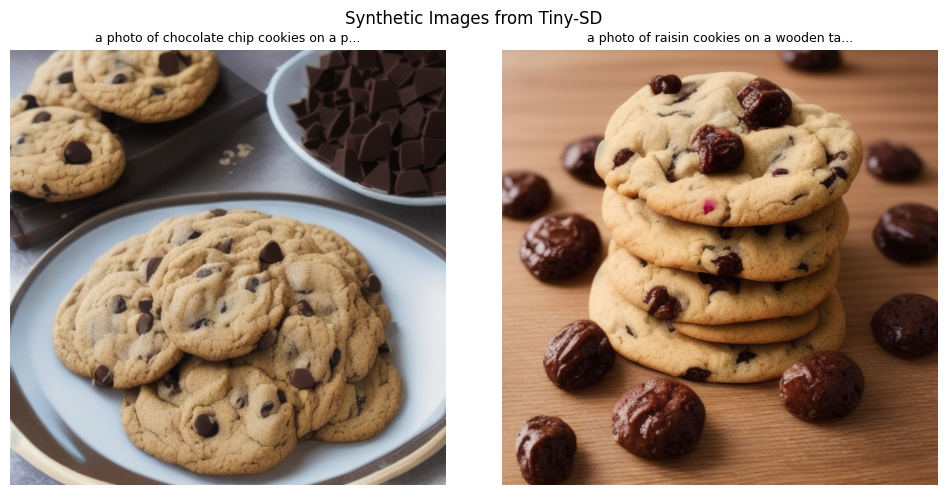

In [22]:
# Generate a few images for our cookie classifier
prompts = [
    'a photo of chocolate chip cookies on a plate, food photography',
    'a photo of raisin cookies on a wooden table, food photography',
]

fig, axes = plt.subplots(1, len(prompts), figsize=(10, 5))
for i, prompt in enumerate(prompts):
    image = pipe(prompt, num_inference_steps=25).images[0]
    axes[i].imshow(image)
    axes[i].set_title(prompt[:40] + '...', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Synthetic Images from Tiny-SD', fontsize=12)
plt.tight_layout()
plt.show()

Synthetic images are most useful for:

- **Augmenting rare classes** — if you have 500 images of class A but only 20 of class B, generate more of B
- **Bootstrapping a dataset** — generate initial images, then replace them with real ones as you collect more
- **Data augmentation** — generate variations of existing images

They are less useful when the task requires photographic realism or domain-specific accuracy (e.g. medical imaging). Always compare model performance on synthetic-only vs. real data to check for distribution shift.

### Generating Tabular Data

You can also use LLMs to generate tabular data. The approach is the same as text generation: describe the schema, ask the model to produce rows, and validate the output. BUT, you need to be very careful because models trained on tabular data want to capture the *relationship* between labels and features. Generated examples might not be able to recreate that realistically.

Here is a quick example using the same DSPy + Qwen3-0.6B setup:

In [23]:
class GenerateCustomerRow(dspy.Signature):
    """Generate a single realistic row of customer data matching the given schema."""
    schema_description = dspy.InputField(
        desc='description of the columns and their types/ranges'
    )
    customer_segment = dspy.InputField(
        desc='the customer segment to generate for, e.g. young professional, retiree'
    )
    age = dspy.OutputField(desc='integer between 18 and 80')
    annual_income = dspy.OutputField(desc='integer in USD, realistic for the segment')
    monthly_spend = dspy.OutputField(desc='integer in USD, realistic for the segment')
    loyalty_score = dspy.OutputField(desc='float between 0.0 and 1.0')


row_generator = dspy.Predict(GenerateCustomerRow)

schema_desc = (
    'Customer data with columns: age (18-80), annual_income (USD), '
    'monthly_spend (USD), loyalty_score (0.0-1.0)'
)

segments = ['young professional', 'college student', 'retiree', 'working parent']
rows = []
for seg in segments:
    result = row_generator(schema_description=schema_desc, customer_segment=seg)
    rows.append({
        'segment': seg,
        'age': result.age,
        'annual_income': result.annual_income,
        'monthly_spend': result.monthly_spend,
        'loyalty_score': result.loyalty_score,
    })

df_tabular = pd.DataFrame(rows)
print('Synthetic tabular data:')
df_tabular

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Synthetic tabular data:


,segment,age,annual_income,monthly_spend,loyalty_score
0,young professional,18,15000,200,0.8
1,college student,18,1500,200,0.8
2,retiree,35,5000,200,0.8
3,working parent,35,5000,200,0.8


This is a simple demonstration. For production-grade tabular data generation with LLMs, see [AdaRec](https://github.com/amazon-science/AdaRec) — a framework that converts tabular customer data into natural language profiles using LLMs, then uses few-shot learning to predict counterfactual outcomes. It demonstrates how LLMs can bridge the gap between structured data and natural language reasoning.

The general principle holds across all modalities: **generate → inspect → curate → validate**. Synthetic data is a tool, not a shortcut.

## 7. Data Quality Checklist

Before you start training a model, run through this checklist. It is aligned with the AI Builders project rubric. If you cannot check every box, your data is not ready.

### The Non-Trivial Effort Test

- [ ] Can you explain where your data came from and why it is appropriate for your task?
- [ ] Did you perform at least one non-trivial data preparation step? (merging sources, scraping, labeling, cleaning, augmenting, generating, etc.)
- [ ] Can you show before/after examples of your data preparation?

### Label Quality

- [ ] Did you manually inspect a random sample of labels (at least 20–50 examples)?
- [ ] Are the labels consistent? (Would two different people assign the same label?)
- [ ] If labels were generated by a model, did you measure and report the error rate?

### Input Quality

- [ ] Did you check for duplicates?
- [ ] Did you check for corrupted or empty inputs (broken images, empty strings, null values)?
- [ ] Did you check for encoding issues (mojibake, wrong character sets)?
- [ ] Did you look at the distribution of input features (lengths, value ranges, mean, median, percentiles, etc.)?

### Train / Validation / Test Splits

- [ ] Are your splits random or stratified (preserving class balance)?
- [ ] Is there zero data leakage between splits? (No duplicate or near-duplicate examples across splits)
- [ ] If your data has a time dimension, did you split by time (not randomly)?
- [ ] Is your test set representative of the real-world distribution you care about?

## 8. Your Data Plan

Fill in the template below to plan the data for your AI Builders project. This will help you think through your data strategy before you start building, and gives your mentors something concrete to review.

In [ ]:
# ============================================================
# YOUR DATA PLAN — fill this in for your project
# ============================================================

# 1. What is your task?
#    Example: 'Classify Thai street food images into 10 categories'
MY_TASK = ''

# 2. Where will your data come from? (be specific — URLs, APIs, dataset names)
#    Example: 'HuggingFace food-101 dataset + 200 images I photograph myself'
MY_DATA_SOURCES = ''

# 3. What makes your data collection non-trivial?
#    What work do YOU have to do beyond downloading?
#    Example: 'food-101 does not have Thai food categories, so I need to
#     re-label 500 images and supplement with my own photos'
MY_DATA_EFFORT = ''

# 4. Estimated dataset size
#    Example: '1,200 images (800 train / 200 val / 200 test)'
MY_DATASET_SIZE = ''

# 5. How will you verify data quality?
#    Example: 'Manual inspection of 50 random samples per class,
#     check for duplicates with image hashing'
MY_QUALITY_PLAN = ''

# 6. Data effort level (circle one): 1 / 2 / 3 / 4
#    Refer to the Data Effort Spectrum in Section 1.
#    Remember: Level 1 is NOT ENOUGH for your project.
MY_EFFORT_LEVEL = 0

# Print your plan
print('=== YOUR DATA PLAN ===')
print(f'Task:           {MY_TASK}')
print(f'Data sources:   {MY_DATA_SOURCES}')
print(f'Non-trivial:    {MY_DATA_EFFORT}')
print(f'Dataset size:   {MY_DATASET_SIZE}')
print(f'Quality plan:   {MY_QUALITY_PLAN}')
print(f'Effort level:   {MY_EFFORT_LEVEL}')
if MY_EFFORT_LEVEL < 2:
    print('\n⚠️  Your effort level needs to be at least 2!')

## What’s Next

You now have the tools to find, collect, generate, and validate data for your project. In Lesson 3, we will go deeper into the training loop — building stochastic gradient descent from scratch so you understand exactly how your model learns from the data you have prepared.

Before next week:

1. Fill in your Data Plan above
2. Start collecting or identifying your project data
3. Run the Data Quality Checklist on whatever data you have so far